# Guitar Classifier — Full Model Comparison

Loads the **best saved checkpoint** from each model and evaluates all of them
on the same held-out test set so results are directly comparable.

| Model | Checkpoint | Dataset used |
|-------|-----------|--------------|
| Baseline CNN | `best_baseline_model.pth` | `dataset/` |
| Improved CNN | `best_adam_lr0.0001_bs64.pth` | `processed_dataset/` |
| Fine-Tuned ResNet18 | `best_resnet18_model.pth` | `dataset/` |

**Classes:** acoustic · bass · electric

> **Colab:** Upload all `.pth` files and both dataset folders to your Google Drive,
> then mount Drive and set `DRIVE_ROOT` below before running.

## 0. Google Drive Mount (Colab only)

In [ ]:
import os

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# ── Set this to the folder that contains your .pth files and dataset folders ──
DRIVE_ROOT = ""   # ← adjust if needed


# Verify
print("[INFO] Drive root:", DRIVE_ROOT)
for item in ["dataset", "processed_dataset",
             "best_baseline_model.pth",
             "best_adam_lr0.0001_bs64.pth",
             "best_resnet18_model.pth"]:
    full = os.path.join(DRIVE_ROOT, item)
    status = "✓" if os.path.exists(full) else "✗ MISSING"
    print(f"  {status}  {item}")

[INFO] Drive root: 
  ✗ MISSING  dataset
  ✗ MISSING  processed_dataset
  ✗ MISSING  best_baseline_model.pth
  ✗ MISSING  best_adam_lr0.0001_bs16.pth
  ✗ MISSING  best_resnet18_model.pth


## 1. Install Dependencies

In [ ]:
# Colab usually has these, but install/upgrade just in case
import subprocess
subprocess.run(["pip3", "install", "-q", "torch", "torchvision",
                "scikit-learn", "seaborn", "matplotlib"], check=True)

CompletedProcess(args=['pip', 'install', '-q', 'torch', 'torchvision', 'scikit-learn', 'seaborn', 'matplotlib'], returncode=0)

## 2. Imports and Reproducibility

In [ ]:
import copy

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve, auc,
)

# ── Reproducibility ───────────────────────────────────────────────────────
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 3. Configuration

In [ ]:
# ── Paths (relative to DRIVE_ROOT set in cell 0) ─────────────────────────
DATA_DIR_BASELINE  = os.path.join(DRIVE_ROOT, "dataset")           # Baseline + ResNet18
DATA_DIR_IMPROVED  = os.path.join(DRIVE_ROOT, "processed_dataset") # Improved CNN

CHECKPOINTS = {
    "Baseline CNN":        os.path.join(DRIVE_ROOT, "best_baseline_model.pth"),
    "Improved CNN":        os.path.join(DRIVE_ROOT, "best_adam_lr0.0001_bs64.pth"),
    "Fine-Tuned ResNet18": os.path.join(DRIVE_ROOT, "best_resnet18_model.pth"),
}

# Each model was trained on a specific dataset directory
MODEL_DATA_DIR = {
    "Baseline CNN":        DATA_DIR_BASELINE,
    "Improved CNN":        DATA_DIR_IMPROVED,
    "Fine-Tuned ResNet18": DATA_DIR_BASELINE,
}

IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_CLASSES = 3
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

## 4. Device

In [ ]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("[INFO] Using CPU")
    return device

device = get_device()

[INFO] GPU: NVIDIA A100-SXM4-40GB


## 5. Data Loading Helper

Reproduces the **exact same 70/15/15 random split** (seed 42) that each model
was trained with, so the test set is identical to what was held out during training.

In [ ]:
def get_test_loader(data_dir, batch_size=BATCH_SIZE):
    """
    Return (test_loader, class_names) using the same 70/15/15 split as training.
    Uses only resize + normalise (no augmentation) for fair evaluation.
    """
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"[ERROR] Dataset not found: {data_dir}")

    eval_tf = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    full_dataset = ImageFolder(root=data_dir, transform=eval_tf)
    class_names  = full_dataset.classes
    n_total      = len(full_dataset)

    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)
    n_test  = n_total - n_train - n_val

    _, _, test_ds = random_split(
        full_dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )

    loader = DataLoader(test_ds, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)

    print(f"[INFO] {os.path.basename(data_dir)} → classes: {class_names}  |  test: {n_test}")
    return loader, class_names


# Pre-load both test loaders (Baseline/ResNet18 share 'dataset'; Improved uses 'processed_dataset')
test_loader_std, class_names_std = get_test_loader(DATA_DIR_BASELINE)
test_loader_imp, class_names_imp = get_test_loader(DATA_DIR_IMPROVED)

MODEL_TEST_LOADER = {
    "Baseline CNN":        test_loader_std,
    "Improved CNN":        test_loader_imp,
    "Fine-Tuned ResNet18": test_loader_std,
}

# Use standard class names for all shared plots
class_names = class_names_std
print("[INFO] Using class names:", class_names)

[INFO] dataset → classes: ['acoustic', 'bass', 'electric']  |  test: 666
[INFO] processed_dataset → classes: ['acoustic', 'bass', 'electric']  |  test: 666
[INFO] Using class names: ['acoustic', 'bass', 'electric']


## 6. Model Architecture Definitions

Each model is **rebuilt exactly as it was during training** so that the
saved state-dict loads without key mismatches.

In [ ]:
# ── 6a. Baseline CNN ─────────────────────────────────────────────────────
class BaselineCNN(nn.Module):
    """3-conv baseline — no BatchNorm, no Dropout."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1);   self.relu1 = nn.ReLU(); self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1);  self.relu2 = nn.ReLU(); self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1); self.relu3 = nn.ReLU(); self.pool3 = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1  = nn.Linear(128 * 28 * 28, 512);     self.relu4 = nn.ReLU()
        self.fc2  = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        return self.fc2(self.relu4(self.fc1(self.flatten(x))))


# ── 6b. Improved CNN ─────────────────────────────────────────────────────
class ImprovedCNN(nn.Module):
    """5-block CNN with BatchNorm + Dropout (trained on processed_dataset)."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.block1 = nn.Sequential(conv_block(3,   32),  nn.MaxPool2d(2, 2))
        self.block2 = nn.Sequential(conv_block(32,  64),  nn.MaxPool2d(2, 2))
        self.block3 = nn.Sequential(conv_block(64,  128), nn.MaxPool2d(2, 2))
        self.block4 = nn.Sequential(conv_block(128, 256), nn.MaxPool2d(2, 2))
        self.block5 = nn.Sequential(conv_block(256, 256), nn.AdaptiveAvgPool2d((4, 4)))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        for blk in [self.block1, self.block2, self.block3, self.block4, self.block5]:
            x = blk(x)
        return self.classifier(x)


# ── 6c. Fine-Tuned ResNet18 ──────────────────────────────────────────────
def build_resnet18(num_classes=NUM_CLASSES):
    """ResNet18 with the custom 2-dropout FC head used during fine-tuning."""
    m = models.resnet18(weights=None)
    in_features = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return m

## 7. Load All Checkpoints

In [ ]:
def load_model(name, checkpoint_path, device):
    """Instantiate, load weights, move to device, set eval mode."""
    constructors = {
        "Baseline CNN":        BaselineCNN,
        "Improved CNN":        ImprovedCNN,
        "Fine-Tuned ResNet18": build_resnet18,
    }
    model = constructors[name]()

    state = torch.load(checkpoint_path, map_location=device)
    # Handle deployment checkpoint format (ResNet18 saves a dict with extra metadata)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]

    model.load_state_dict(state)
    model.to(device).eval()

    total_p = sum(p.numel() for p in model.parameters())
    print(f"[INFO] Loaded '{name}'  |  {total_p:,} parameters")
    return model


models_dict = {}
for name, ckpt in CHECKPOINTS.items():
    models_dict[name] = load_model(name, ckpt, device)

[INFO] Loaded 'Baseline CNN'  |  51,475,523 parameters
[INFO] Loaded 'Improved CNN'  |  3,143,971 parameters
[INFO] Loaded 'Fine-Tuned ResNet18'  |  11,308,611 parameters


## 8. Evaluation Function

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, device):
    """Return (true_labels, predictions, softmax_probs) arrays."""
    all_labels, all_preds, all_probs = [], [], []
    model.eval()
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        probs  = torch.softmax(logits, dim=1)
        _, preds = torch.max(logits, 1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

## 9. Run Evaluation on All Models

In [ ]:
results = {}

for name, model in models_dict.items():
    print(f"\n{'='*60}\n  Evaluating: {name}\n{'='*60}")

    loader = MODEL_TEST_LOADER[name]
    labels, preds, probs = evaluate_model(model, loader, device)

    acc  = (labels == preds).mean()
    prec = precision_score(labels, preds, average="weighted", zero_division=0)
    rec  = recall_score(labels, preds, average="weighted", zero_division=0)
    f1   = f1_score(labels, preds, average="weighted", zero_division=0)

    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}    (weighted)")
    print(f"  F1-score  : {f1:.4f}       (weighted)")

    # Use the correct class names for each model's dataset
    cnames = class_names_imp if name == "Improved CNN" else class_names_std
    print()
    print(classification_report(labels, preds, target_names=cnames, digits=4))

    results[name] = dict(labels=labels, preds=preds, probs=probs,
                         acc=acc, precision=prec, recall=rec, f1=f1)

best_name = max(results, key=lambda n: results[n]["acc"])


  Evaluating: Baseline CNN
  Accuracy  : 66.52%
  Precision : 0.6690  (weighted)
  Recall    : 0.6652    (weighted)
  F1-score  : 0.6647       (weighted)

              precision    recall  f1-score   support

    acoustic     0.7212    0.7342    0.7277       222
        bass     0.6889    0.5794    0.6294       214
    electric     0.6000    0.6783    0.6367       230

    accuracy                         0.6652       666
   macro avg     0.6700    0.6640    0.6646       666
weighted avg     0.6690    0.6652    0.6647       666


  Evaluating: Improved CNN
  Accuracy  : 74.62%
  Precision : 0.7613  (weighted)
  Recall    : 0.7462    (weighted)
  F1-score  : 0.7412       (weighted)

              precision    recall  f1-score   support

    acoustic     0.6962    0.9189    0.7922       222
        bass     0.8456    0.5888    0.6942       214
    electric     0.7455    0.7261    0.7357       230

    accuracy                         0.7462       666
   macro avg     0.7625    0.7446  

## 10. Summary Table

In [ ]:
print(f"\n{'='*75}")
print(f"  FULL MODEL COMPARISON — TEST SET RESULTS")
print(f"{'='*75}")
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 75)
for name, r in results.items():
    marker = " ← BEST" if name == best_name else ""
    print(f"{name:<25} {r['acc']*100:>8.2f}%  {r['precision']:>9.4f}  "
          f"{r['recall']:>7.4f}  {r['f1']:>7.4f}{marker}")
print("=" * 75)


  FULL MODEL COMPARISON — TEST SET RESULTS
Model                      Accuracy  Precision   Recall       F1
---------------------------------------------------------------------------
Baseline CNN                 66.52%     0.6690   0.6652   0.6647
Improved CNN                 74.62%     0.7613   0.7462   0.7412
Fine-Tuned ResNet18          90.54%     0.9053   0.9054   0.9053 ← BEST


## 11. Bar Chart — Accuracy, Precision, Recall, F1

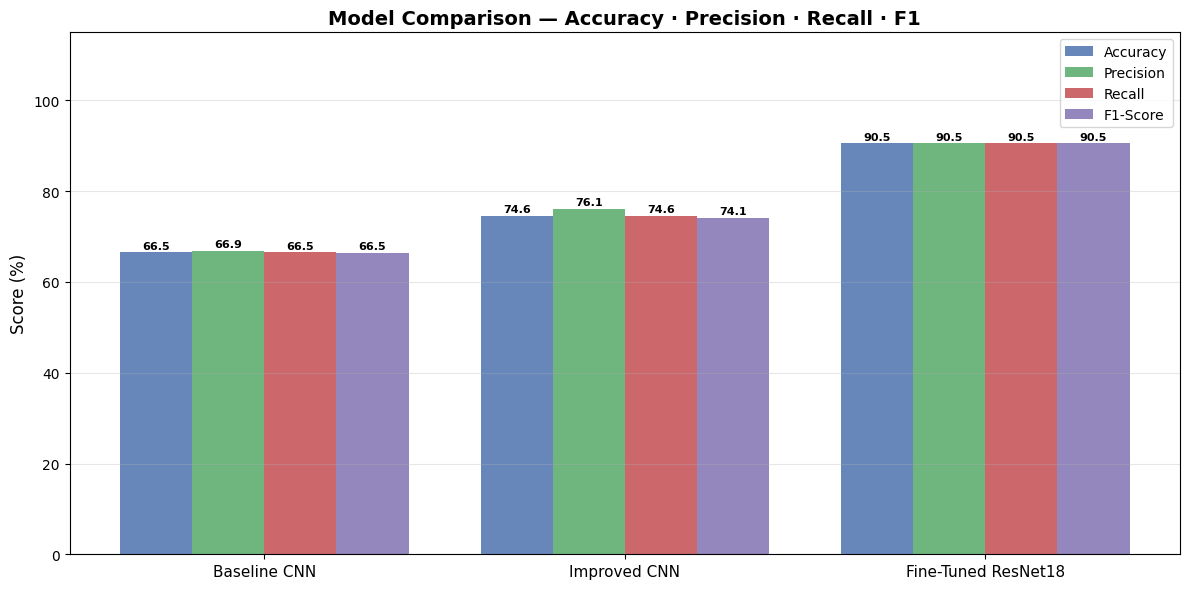

In [ ]:
def plot_metric_comparison(results):
    model_names   = list(results.keys())
    metrics       = ["acc", "precision", "recall", "f1"]
    metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
    colors        = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

    x     = np.arange(len(model_names))
    width = 0.20

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
        vals = [results[n][metric] * 100 for n in model_names]
        bars = ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel("Score (%)", fontsize=12)
    ax.set_title("Model Comparison — Accuracy · Precision · Recall · F1",
                 fontsize=14, fontweight="bold")
    ax.set_ylim(0, 115)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_comparison(results)

## 12. Confusion Matrices (Side by Side)

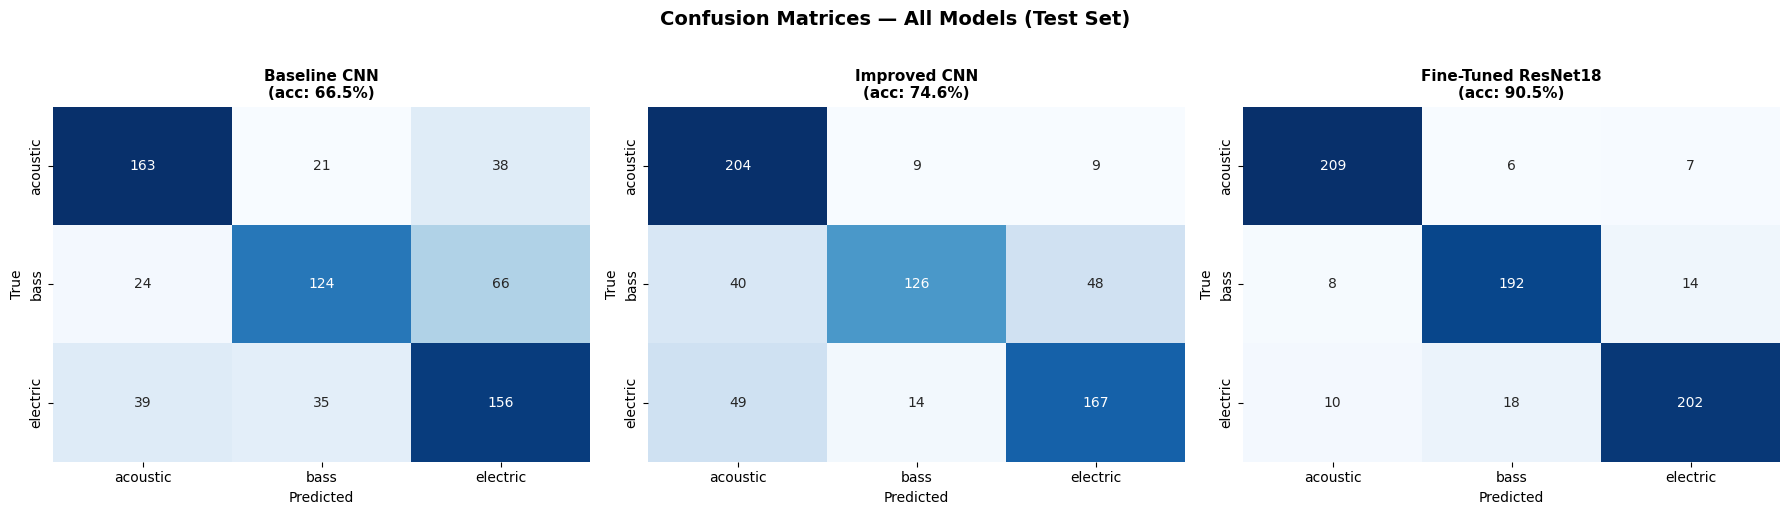

In [ ]:
def plot_all_confusion_matrices(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (name, r) in zip(axes, results.items()):
        cnames = class_names_imp if name == "Improved CNN" else class_names_std
        cm = confusion_matrix(r["labels"], r["preds"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=cnames, yticklabels=cnames,
                    ax=ax, cbar=False)
        ax.set_title(f"{name}\n(acc: {r['acc']*100:.1f}%)",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.suptitle("Confusion Matrices — All Models (Test Set)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_all_confusion_matrices(results)

## 13. Per-Class F1 Comparison

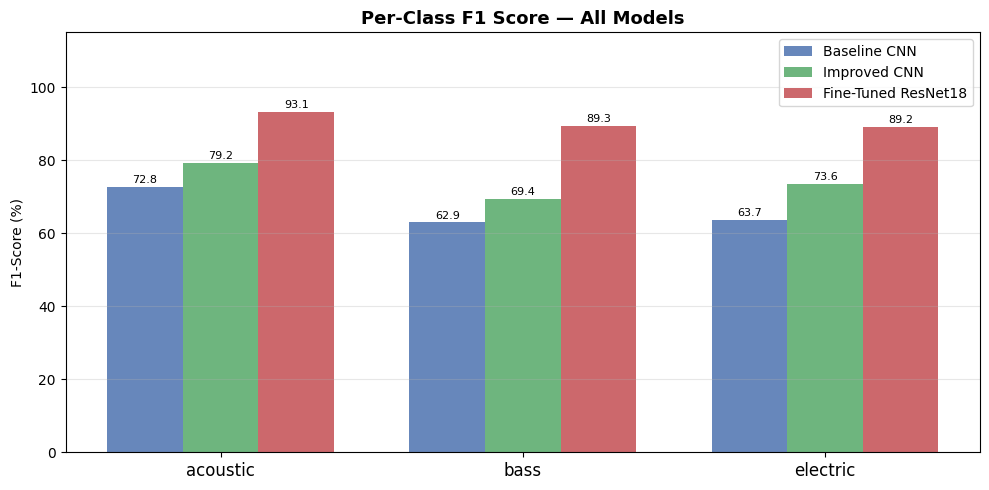

In [ ]:
def plot_per_class_f1(results):
    model_names = list(results.keys())
    x           = np.arange(len(class_names))
    width       = 0.25
    colors      = ["#4C72B0", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (name, color) in enumerate(zip(model_names, colors)):
        r  = results[name]
        f1 = f1_score(r["labels"], r["preds"], average=None, zero_division=0)
        bars = ax.bar(x + i * width, f1 * 100, width, label=name,
                      color=color, alpha=0.85)
        for bar, val in zip(bars, f1 * 100):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width * (len(model_names) - 1) / 2)
    ax.set_xticklabels(class_names, fontsize=12)
    ax.set_ylabel("F1-Score (%)")
    ax.set_title("Per-Class F1 Score — All Models", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 115)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_per_class_f1(results)

## 14. ROC Curves (One-vs-Rest, per class)

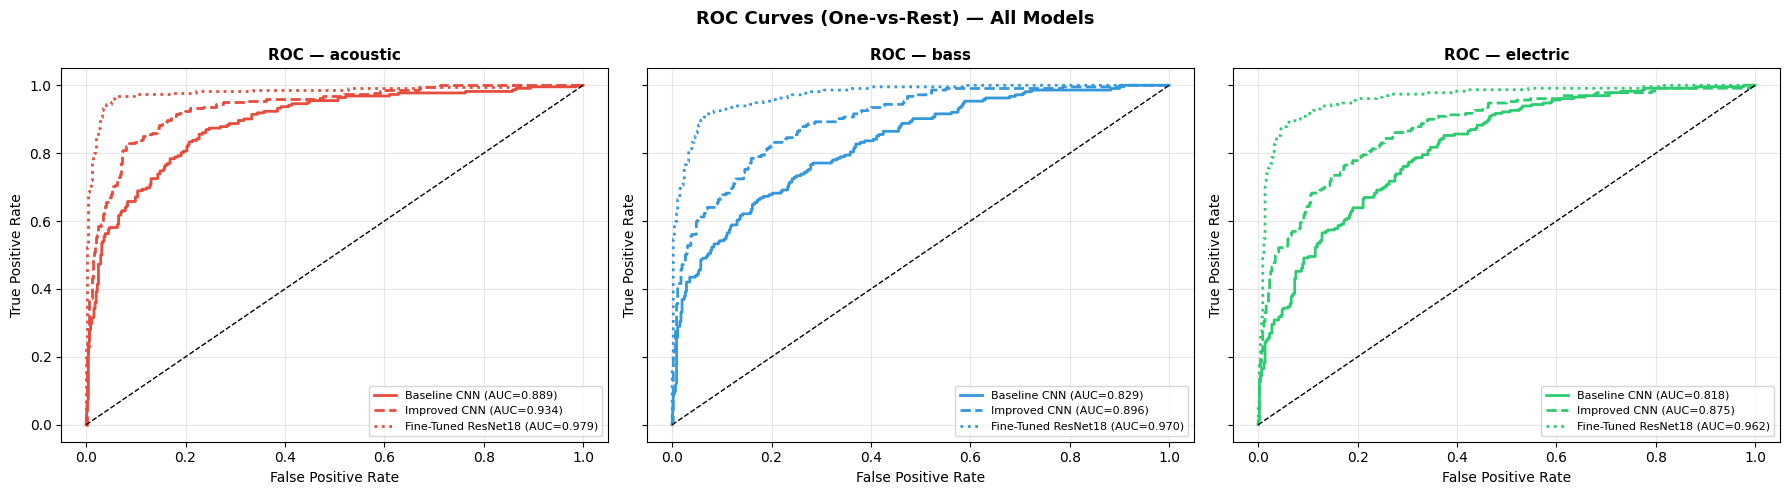

In [ ]:
def plot_roc_curves(results):
    n_classes    = len(class_names)
    model_names  = list(results.keys())
    line_styles  = ["-", "--", ":"]
    class_colors = ["#e74c3c", "#3498db", "#2ecc71"]

    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)
    if n_classes == 1:
        axes = [axes]

    for cls_idx, (cls_name, ax, color) in enumerate(zip(class_names, axes, class_colors)):
        for model_name, ls in zip(model_names, line_styles):
            r          = results[model_name]
            y_true_bin = (r["labels"] == cls_idx).astype(int)
            y_score    = r["probs"][:, cls_idx]
            fpr, tpr, _ = roc_curve(y_true_bin, y_score)
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr, linestyle=ls, color=color, lw=2,
                    label=f"{model_name} (AUC={roc_auc:.3f})")

        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set_title(f"ROC — {cls_name}", fontsize=11, fontweight="bold")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle("ROC Curves (One-vs-Rest) — All Models",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_roc_curves(results)

## 15. Sample Predictions — All Models on the Same Images

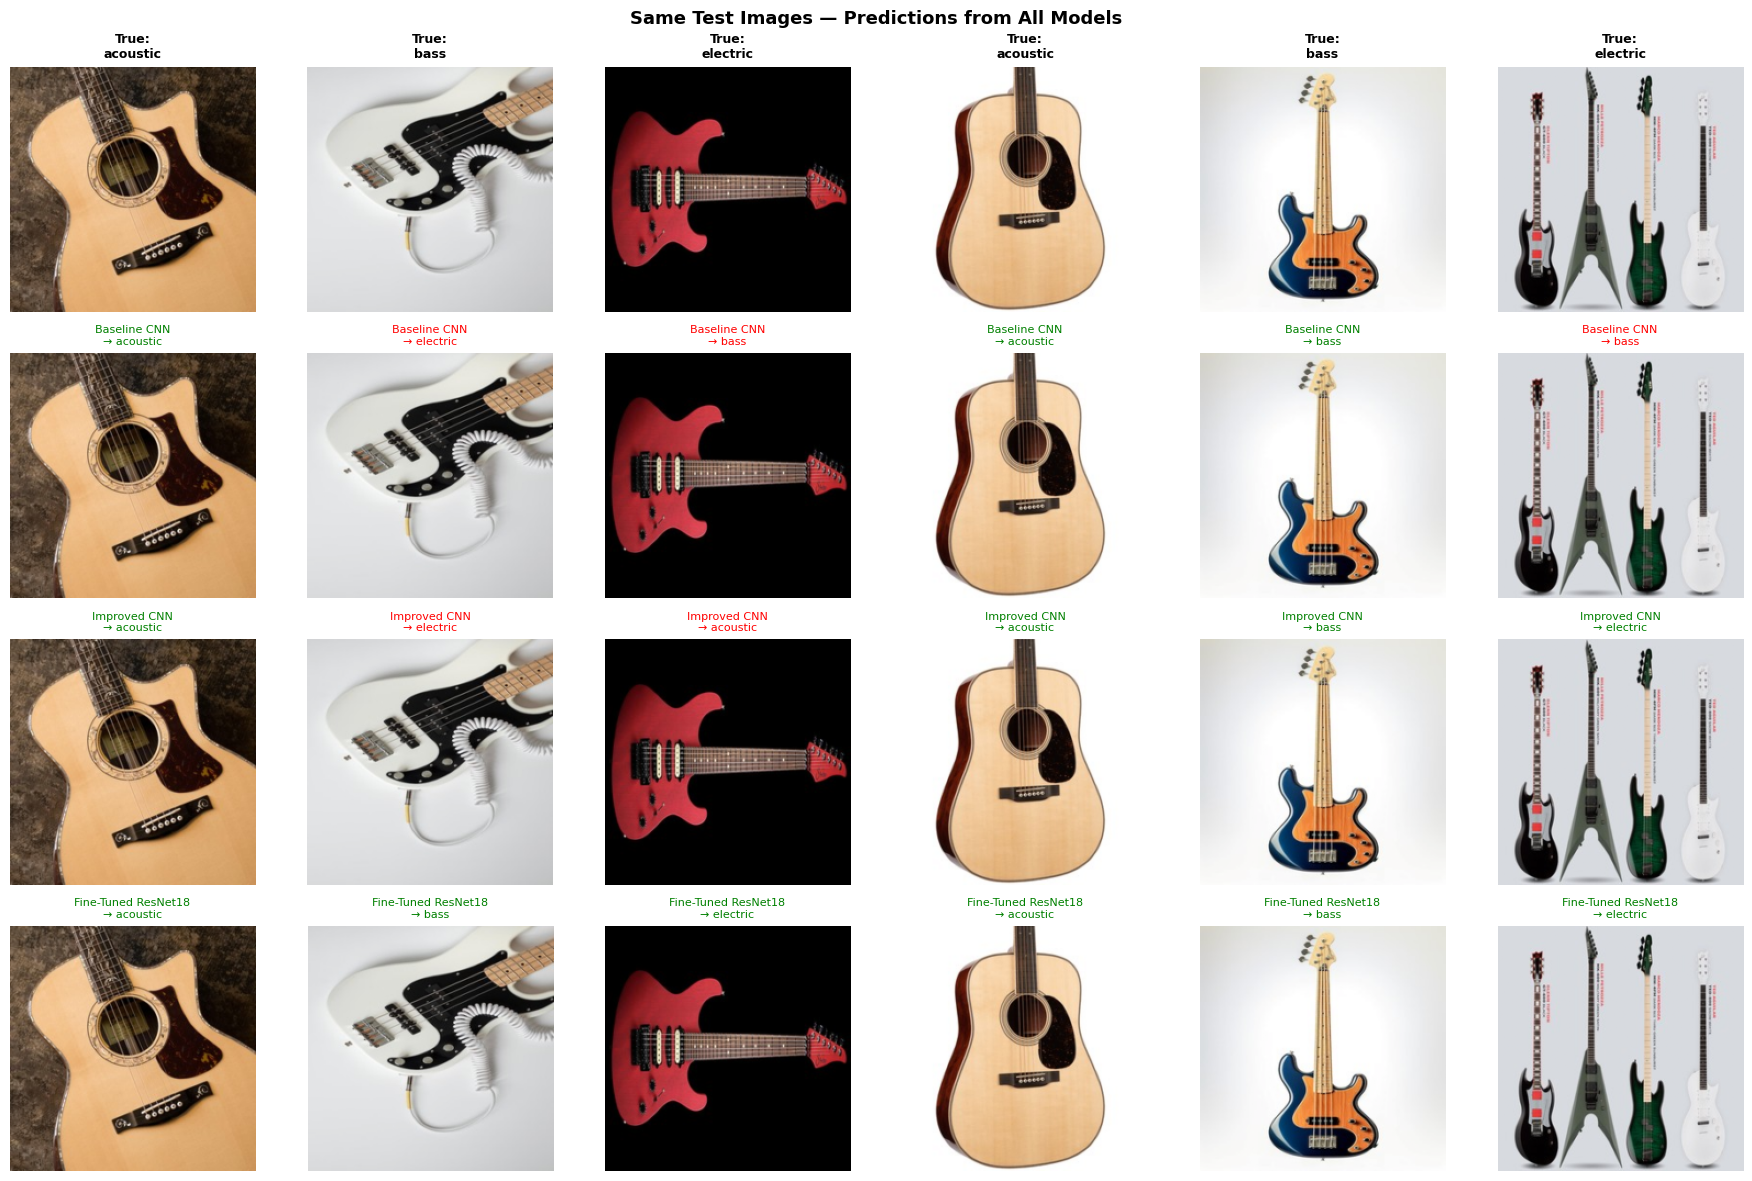

In [ ]:
def plot_sample_predictions_all(models_dict, test_loader_std, class_names, device, n=6):
    """
    Show n images from the shared test loader.
    Each row below the image shows one model's prediction (green = correct, red = wrong).
    """
    images_batch, labels_batch = next(iter(test_loader_std))
    images_batch = images_batch[:n]
    labels_batch = labels_batch[:n]

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    model_names     = list(models_dict.keys())
    preds_per_model = {}
    for name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            out = model(images_batch.to(device))
            _, p = torch.max(out, 1)
        preds_per_model[name] = p.cpu()

    n_rows = len(model_names) + 1
    fig, axes = plt.subplots(n_rows, n, figsize=(3 * n, 3 * n_rows))

    for col in range(n):
        img = (images_batch[col] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        # Top row: image + true label
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"True:\n{class_names[labels_batch[col]]}",
                               fontsize=9, fontweight="bold")
        axes[0, col].axis("off")

        # One row per model
        for row, name in enumerate(model_names, start=1):
            pred_idx   = preds_per_model[name][col].item()
            true_idx   = labels_batch[col].item()
            color      = "green" if pred_idx == true_idx else "red"
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"{name}\n→ {class_names[pred_idx]}",
                                     color=color, fontsize=8)
            axes[row, col].axis("off")

    for row, label in enumerate(["Image"] + model_names):
        axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=80, va="center")

    plt.suptitle("Same Test Images — Predictions from All Models",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_sample_predictions_all(models_dict, test_loader_std, class_names, device)

## 16. Final Summary

In [ ]:
print(f"\n{'='*75}")
print(f"  FINAL COMPARISON SUMMARY (sorted by accuracy)")
print(f"{'='*75}")
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 75)
for name, r in sorted(results.items(), key=lambda x: x[1]["acc"], reverse=True):
    marker = " ← BEST" if name == best_name else ""
    print(f"{name:<25} {r['acc']*100:>8.2f}%  {r['precision']:>9.4f}  "
          f"{r['recall']:>7.4f}  {r['f1']:>7.4f}{marker}")
print("=" * 75)

print("\n  Per-Class F1 Breakdown:")
print(f"  {'Model':<25}", end="")
for c in class_names:
    print(f"  {c:>10}", end="")
print()
print("  " + "-" * (25 + 12 * len(class_names)))
for name, r in results.items():
    pc_f1 = f1_score(r["labels"], r["preds"], average=None, zero_division=0)
    print(f"  {name:<25}", end="")
    for val in pc_f1:
        print(f"  {val*100:>9.1f}%", end="")
    print()
print("=" * 75)


  FINAL COMPARISON SUMMARY (sorted by accuracy)
Model                      Accuracy  Precision   Recall       F1
---------------------------------------------------------------------------
Fine-Tuned ResNet18          90.54%     0.9053   0.9054   0.9053 ← BEST
Improved CNN                 74.62%     0.7613   0.7462   0.7412
Baseline CNN                 66.52%     0.6690   0.6652   0.6647

  Per-Class F1 Breakdown:
  Model                        acoustic        bass    electric
  -------------------------------------------------------------
  Baseline CNN                    72.8%       62.9%       63.7%
  Improved CNN                    79.2%       69.4%       73.6%
  Fine-Tuned ResNet18             93.1%       89.3%       89.2%
